In [3]:
import pandas as pd
import networkx as nx

In [4]:
df = pd.read_csv('http://mlg.ucd.ie/modules/COMP30850/transactions.csv')

In [5]:
df.head()

,day,month,year,source,destination,amount
0,1,October,2024,5793,5179,121.00
1,1,October,2024,5664,5466,75.09
2,1,October,2024,5855,5150,15.60
3,1,October,2024,5855,5150,10.20
4,1,October,2024,5699,5467,184.30


In [6]:
import pandas as pd
import networkx as nx

df = pd.read_csv('http://mlg.ucd.ie/modules/COMP30850/transactions.csv')

G = nx.DiGraph()

for index, row in df.iterrows():
    sender = row['source']
    receiver = row['destination']
    amount = row['amount']
    
    if G.has_edge(sender, receiver):
        G[sender][receiver]['weight'] += amount
        G[sender][receiver]['transactions'] += 1
    else:
        G.add_edge(sender, receiver, weight=amount, transactions=1)

# Justification:
# A directed graph (DiGraph) is chosen because financial transactions have a clear direction from sender to receiver.
# Multiple transactions between the same pair of accounts are aggregated by summing their amounts into an edge 'weight' and counting them with a 'transactions' attribute.

In [6]:
G = nx.DiGraph()
for index, row in df.iterrows():
    source = row['source']
    destination = row['destination']
    if G.has_edge(source, destination):
        G[source][destination]['weight'] += 1
    else:
        G.add_edge(source, destination, weight=1)

In [8]:
print(f"Network Density: {nx.density(G):.4f}")
print(f"Reciprocity: {nx.reciprocity(G):.4f}")

Network Density: 0.0064
Reciprocity: 0.0118


The low network density suggests that only a small fraction of all possible transactions between entities actually occur. The very low reciprocity indicates that most transactions are one-way, with little money flowing back from the recipient to the original sender.

In [10]:
def get_weighted_in_degree(node):
    return G.in_degree(node, weight='weight')

def get_weighted_out_degree(node):
    return G.out_degree(node, weight='weight')

top_10_in_degree = sorted(G.nodes(), key=get_weighted_in_degree, reverse=True)[:10]
top_10_out_degree = sorted(G.nodes(), key=get_weighted_out_degree, reverse=True)[:10]

print("Top 10 accounts by Weighted In-Degree:")
for i, account in enumerate(top_10_in_degree):
    print(f"{i+1}. Account: {account}, Weighted In-Degree: {G.in_degree(account, weight='weight')}")

print("\nTop 10 accounts by Weighted Out-Degree:")
for i, account in enumerate(top_10_out_degree):
    print(f"{i+1}. Account: {account}, Weighted Out-Degree: {G.out_degree(account, weight='weight')}")

Top 10 accounts by Weighted In-Degree:
1. Account: 5150, Weighted In-Degree: 358
2. Account: 5466, Weighted In-Degree: 275
3. Account: 5359, Weighted In-Degree: 219
4. Account: 5467, Weighted In-Degree: 215
5. Account: 5179, Weighted In-Degree: 201
6. Account: 5050, Weighted In-Degree: 142
7. Account: 5723, Weighted In-Degree: 109
8. Account: 5654, Weighted In-Degree: 100
9. Account: 5853, Weighted In-Degree: 91
10. Account: 5379, Weighted In-Degree: 89

Top 10 accounts by Weighted Out-Degree:
1. Account: 5050, Weighted Out-Degree: 149
2. Account: 5379, Weighted Out-Degree: 120
3. Account: 5172, Weighted Out-Degree: 119
4. Account: 5356, Weighted Out-Degree: 116
5. Account: 5819, Weighted Out-Degree: 103
6. Account: 5083, Weighted Out-Degree: 103
7. Account: 5403, Weighted Out-Degree: 72
8. Account: 5743, Weighted Out-Degree: 72
9. Account: 5705, Weighted Out-Degree: 70
10. Account: 5185, Weighted Out-Degree: 68


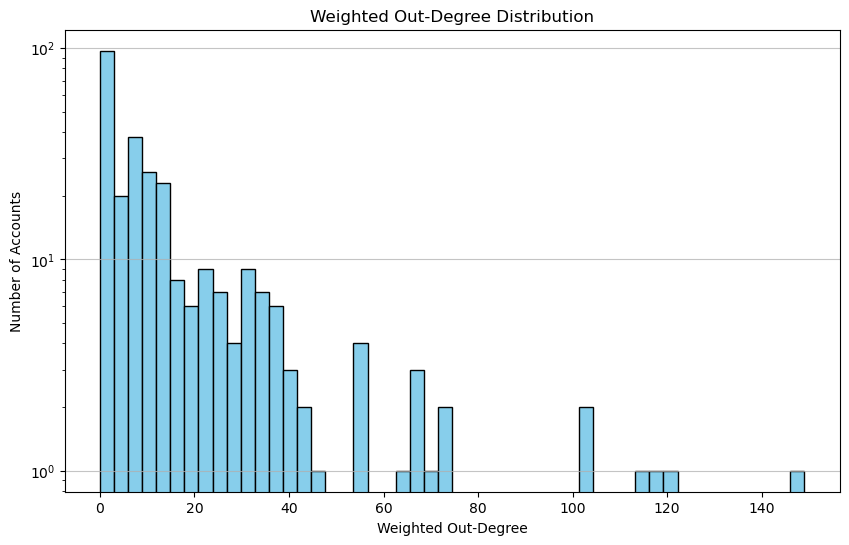

In [13]:
import matplotlib.pyplot as plt
import numpy as np

out_degrees = [G.out_degree(node, weight='weight') for node in G.nodes()]

plt.figure(figsize=(10, 6))
plt.hist(out_degrees, bins=50, color='skyblue', edgecolor='black')
plt.title('Weighted Out-Degree Distribution')
plt.xlabel('Weighted Out-Degree')
plt.ylabel('Number of Accounts')
plt.yscale('log')
plt.grid(axis='y', alpha=0.75)
plt.show()

Weighted out-degree sums the values of transactions initiated by an account, showing the total financial outflow. Unweighted out-degree counts only the number of distinct transactions initiated, regardless of their value. In a financial network, weighted out-degree reveals an account's total spending or investment, while unweighted out-degree shows how many different entities an account transacts with.